# Star Classification using Machine Learning

This notebook explores the classification of stars, galaxies, and quasars based on their spectral characteristics using different machine learning algorithms:
- **K-Nearest Neighbors (KNN)**
- **K-Means Clustering**
- **Decision Trees**

The goal is to apply these models, evaluate their performance, and visualize their respective behaviors (such as identifying Clusters and plotting the Decision Tree).

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, silhouette_score, confusion_matrix

In [16]:
df = pd.read_csv("star_classification.csv")
print(df.shape)

(100000, 18)


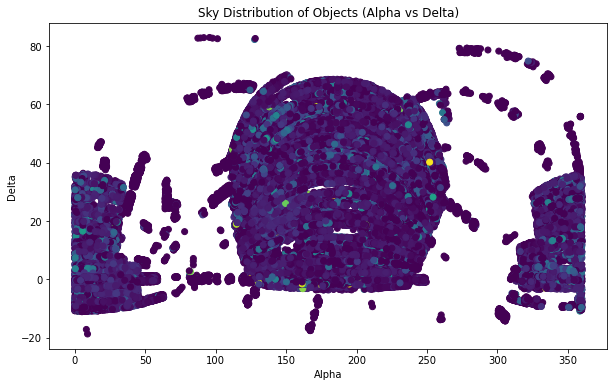

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df["alpha"], df["delta"], cmap='viridis', c = df["redshift"])
plt.title('Sky Distribution of Objects (Alpha vs Delta)')
plt.xlabel('Alpha')
plt.ylabel('Delta')
plt.show()


In [18]:
df_model = df.drop(["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "plate", "MJD", "fiber_ID"], axis = "columns")
print(df_model.isna().sum())
print(f"Duplicate rows : {df_model.duplicated().sum()}")

alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
dtype: int64
Duplicate rows : 0


In [19]:
le_class = LabelEncoder()
df_model["class_n"] = le_class.fit_transform(df_model["class"])
class_mapping = dict(zip(le_class.classes_, le_class.transform(le_class.classes_)))
print(f"Class mapping: {class_mapping}")

Class mapping: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}


In [20]:
print(df_model.head())
print(df_model.describe())
print(df_model.shape)

        alpha      delta         u         g         r         i         z  \
0  135.689107  32.494632  23.87882  22.27530  20.39501  19.16573  18.79371   
1  144.826101  31.274185  24.77759  22.83188  22.58444  21.16812  21.61427   
2  142.188790  35.582444  25.26307  22.66389  20.60976  19.34857  18.94827   
3  338.741038  -0.402828  22.13682  23.77656  21.61162  20.50454  19.25010   
4  345.282593  21.183866  19.43718  17.58028  16.49747  15.97711  15.54461   

    class  redshift  class_n  
0  GALAXY  0.634794        0  
1  GALAXY  0.779136        0  
2  GALAXY  0.644195        0  
3  GALAXY  0.932346        0  
4  GALAXY  0.116123        0  
               alpha          delta              u              g  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean      177.629117      24.135305      21.980468      20.531387   
std        96.502241      19.644665      31.769291      31.750292   
min         0.005528     -18.785328   -9999.000000   -9999.000000   


In [21]:
scaler = StandardScaler()
X = df_model.drop(["class", "class_n"], axis = "columns")
X_scaled = scaler.fit_transform(X)

In [22]:
y = df_model["class_n"]
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)

(80000, 8)
(20000, 8)


## K-Nearest Neighbors (KNN)

**How it works:** KNN is a simple, supervised machine learning algorithm used for classification and regression. It classifies a new data point based on the majority class of its 'K' nearest neighbors in the feature space. 

**Distance Metrics:** The concept of "nearest" relies on calculating the distance between data points. Common distance metrics include:
- **Euclidean Distance:** The straight-line distance between two points. It is the most commonly used metric. ($d = \sqrt{\sum (x_i - y_i)^2}$)
- **Manhattan Distance:** The sum of the absolute differences of their Cartesian coordinates. ($d = \sum |x_i - y_i|$)
- **Minkowski Distance:** A generalized metric that can represent both Euclidean and Manhattan distances depending on a parameter 'p'.

**When to use it:** KNN is best used when the dataset is relatively small, the decision boundary is highly irregular, and there is no need to understand the underlying relationship between features. It is computationally expensive during prediction on very large datasets because distances to all training points must be computed.

Accuracy for KNN Classification is 0.94


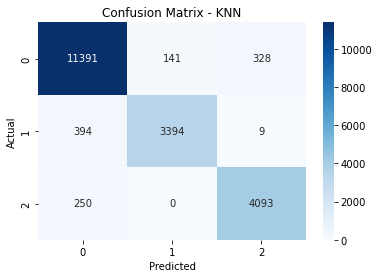

In [23]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f"Accuracy for KNN Classification is {round(accuracy_score(y_test, y_pred), 2)}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## K-Means Clustering

**How it works:** K-Means is an unsupervised learning algorithm that partitions unlabeled data into 'K' distinct clusters. It works iteratively by initializing K centroids, assigning each data point to the closest centroid, and then updating the centroids to be the mean of the newly formed clusters.

**Distance Metrics:** Similar to KNN, K-Means depends heavily on a distance metric to determine the "closest" centroid:
- **Euclidean Distance** is almost exclusively used in standard K-Means. Because K-Means updates centroids by calculating the *mean* of the points, Euclidean distance ensures that the algorithm minimizes the Within-Cluster Sum of Squares (WCSS) or Inertia. 
- Using other distances (like Manhattan) with mean-based centroids can cause the algorithm to fail to converge, which is why variants like K-Medians are used when other distance metrics are required.

**When to use it:** It is widely used for exploratory data analysis, customer segmentation, and anomaly detection. K-Means works best when the clusters are roughly spherical and similar in size, and when you can estimate the optimal number of clusters (e.g., using the Elbow Method).

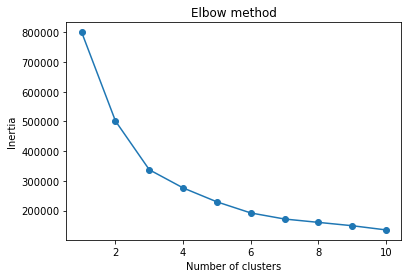

In [24]:
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [25]:
kmeans_final = KMeans(n_clusters=6, random_state=42)
kmeans_final.fit(X_train)

y_pred = kmeans_final.predict(X_test)
print(f"Silhouette score is {round(silhouette_score(X_test, y_pred), 2)}")

Silhouette score is 0.3


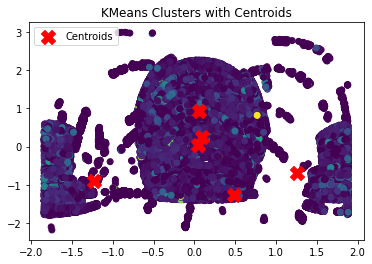

In [26]:
centroids = kmeans_final.cluster_centers_
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["redshift"])
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('KMeans Clusters with Centroids')
plt.legend()
plt.show()

## Decision Trees

**How it works:** A Decision Tree is a supervised learning algorithm that repeatedly splits the data into subsets. The goal is to choose feature splits that best separate the data into pure classes. The result is a flowchart-like tree structure, where each internal node represents a test on a feature, and each leaf node represents a final class label.

**Splitting Criteria (Gini Index & Entropy):** To decide which feature to split on, the tree evaluates the "impurity" or disorder of the resulting child nodes.
- **Entropy:** A measure of randomness or unpredictability in the node. If a node contains only one class, its entropy is 0 (pure). If it has an equal number of all classes, entropy is at its maximum. The algorithm seeks to maximize **Information Gain**, which is the reduction in entropy after a split.
- **Gini Index (or Gini Impurity):** A measure of how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset. Like entropy, a Gini index of 0 indicates perfect purity. It is computationally faster than entropy because it doesn't require computing logarithms.

**When to use it:** Decision Trees are highly interpretable, easily explainable, and naturally handle non-linear relationships without requiring feature scaling. However, they are prone to overfitting noisy data if the tree depth is not constrained.

Accuracy for Decision Tree Classification is 0.96


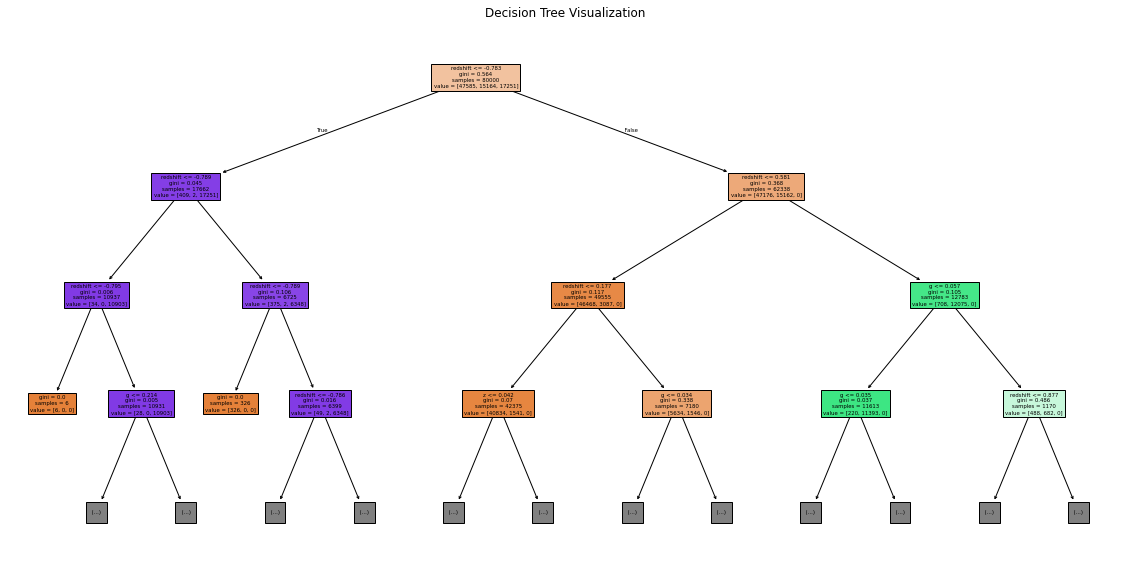

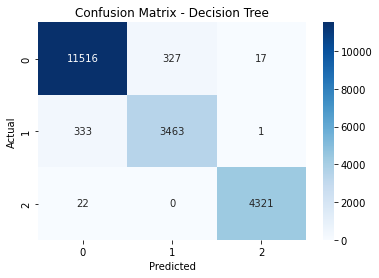

In [27]:
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X_train, y_train)

y_pred = dtree.predict(X_test)
print(f"Accuracy for Decision Tree Classification is {round(accuracy_score(y_test, y_pred), 2)}")

plt.figure(figsize=(20, 10))
tree.plot_tree(dtree,
               max_depth=3,         # Only plot top 3 levels
               filled=True,         # Color the nodes
               feature_names=X.columns,
               )
plt.title('Decision Tree Visualization')
plt.show()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()